# Đánh giá công thức $C_{ij}$ + Louvain với ground truth

Pipeline duy nhất trong notebook:

```text
algorithm_input.json
  → tính C_ij đúng theo công thức
  → tính w_ij = G_ij(βT_ij + γC_ij)
  → threshold + k-NN
  → Louvain
  → khóa nhãn dự đoán
  → mở ground_truth.json để chấm ARI/NMI/pairwise F1
```

$$C_{ij}=\frac{m_{ij}}{2}\exp\left[-I_F\frac{|F_i-F_j|}{\tau_F}-I_E\frac{|E_i-E_j|}{\tau_E}\right],\quad m_{ij}=I_F+I_E,$$

và $C_{ij}=0$ nếu $m_{ij}=0$. `ground_truth.json` không được truyền vào hàm dự đoán. `latent_incidents.json` và `observable_reports.json` không được đọc.


In [1]:
from google.colab import drive
from pathlib import Path
import zipfile

drive.mount('/content/drive')

# Sửa hai dòng này nếu vị trí hoặc tên file trên Drive khác.
DRIVE_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/data')
DATA_ZIP_NAME = 'flood_hybrid_EMSR848_80_runs (1).zip'
DATA_ZIP = DRIVE_DATA_DIR / DATA_ZIP_NAME
DATA_WORK = Path('/content/cij_ground_truth_data')
RESULTS_ROOT = DRIVE_DATA_DIR / 'cij_vs_ground_truth_results'

assert DATA_ZIP.is_file(), f'Không tìm thấy: {DATA_ZIP}'
if not list(DATA_WORK.rglob('run_001/algorithm_input.json')):
    DATA_WORK.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DATA_ZIP) as archive:
        archive.extractall(DATA_WORK)

algorithm_files = sorted(DATA_WORK.rglob('run_*/algorithm_input.json'))
assert len(algorithm_files) == 80, f'Cần 80 run, tìm thấy {len(algorithm_files)}'
run_dirs = [path.parent for path in algorithm_files]
assert len({path.name for path in run_dirs}) == 80
for run_dir in run_dirs:
    assert (run_dir / 'ground_truth.json').is_file(), f'Thiếu ground truth: {run_dir}'
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
print('Dữ liệu:', DATA_ZIP)
print('Số run:', len(run_dirs), run_dirs[0].name, '→', run_dirs[-1].name)
print('Kết quả:', RESULTS_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dữ liệu: /content/drive/MyDrive/Colab Notebooks/data/flood_hybrid_EMSR848_80_runs (1).zip
Số run: 80 run_001 → run_080
Kết quả: /content/drive/MyDrive/Colab Notebooks/data/cij_vs_ground_truth_results


In [2]:
# Cài môi trường sạch; tự restart đúng một lần nếu phải thay binary NumPy.
import importlib.metadata as package_metadata
import os
import subprocess
import sys
from pathlib import Path

print(sys.version)
assert sys.version_info[:2] == (3, 12), 'Hãy chọn Runtime dùng Python 3.12.'
REQUIRED = {
    'numpy': '2.5.1', 'pandas': '3.0.3', 'matplotlib': '3.11.0',
    'networkx': '3.6.1', 'python-louvain': '0.16',
    'scikit-learn': '1.9.0', 'scipy': '1.18.0',
}
MARKER = Path('/content/.cij_vs_gt_dependencies_v1')
if not MARKER.is_file():
    specs = [f'{name}=={version}' for name, version in REQUIRED.items()]
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade',
                    '--upgrade-strategy', 'only-if-needed', *specs], check=True)
    MARKER.write_text('ready', encoding='utf-8')
    print('Đã cài xong. Colab tự restart; sau khi kết nối lại hãy Run all lần nữa.')
    os.kill(os.getpid(), 9)
installed = {name: package_metadata.version(name) for name in REQUIRED}
assert installed == REQUIRED, f'Phiên bản không khớp: {installed}'
check = subprocess.run(
    [sys.executable, '-c', 'import numpy,scipy,sklearn,community; print(numpy.__version__)'],
    check=True, capture_output=True, text=True,
)
print('PASS dependencies; NumPy =', check.stdout.strip())


3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PASS dependencies; NumPy = 2.5.1


In [3]:
import json
import math
import time
from dataclasses import dataclass, replace
from datetime import datetime

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from community import community_louvain
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

FORMULA_VERSION = 'paper-missing-aware-cij-v1'
LOUVAIN_VERSION = package_metadata.version('python-louvain')

@dataclass(frozen=True)
class Params:
    sigma_geo_m: float = 700.0
    tau_temp_min: float = 45.0
    tau_f: float = 0.25
    tau_e: float = 0.35
    beta: float = 0.5
    gamma: float = 0.5
    edge_threshold: float = 0.05
    knn: int = 12
    resolution: float = 1.0
    random_state: int = 42

P = Params()
print('Công thức:', FORMULA_VERSION)
print('Louvain:', LOUVAIN_VERSION, '| params:', P)

def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def parse_algorithm_input(payload):
    rows = payload['reports']
    return {
        'event_id': [row['event_id'] for row in rows],
        'lat': np.array([float(row['lat']) for row in rows]),
        'lng': np.array([float(row['lng']) for row in rows]),
        'time_min': np.array([datetime.fromisoformat(row['created_at']).timestamp() / 60 for row in rows]),
        'flood': np.array([float(row['flood']) for row in rows]),
        'urgency': np.array([float(row['urgency']) for row in rows]),
        'obs_f': np.array(['flood' not in row.get('missing_fields', []) for row in rows], dtype=bool),
        'obs_e': np.array(['urgency' not in row.get('missing_fields', []) for row in rows], dtype=bool),
    }

def scalar_cij(f_i, e_i, missing_i, f_j, e_j, missing_j, p=P):
    i_f = int('flood' not in missing_i and 'flood' not in missing_j)
    i_e = int('urgency' not in missing_i and 'urgency' not in missing_j)
    m_ij = i_f + i_e
    if m_ij == 0:
        return 0.0
    return (m_ij / 2.0) * math.exp(
        -i_f * abs(f_i - f_j) / p.tau_f
        -i_e * abs(e_i - e_j) / p.tau_e
    )

def build_weight_matrix(x, p=P):
    lat, lng = np.radians(x['lat']), np.radians(x['lng'])
    dlat = lat[:, None] - lat[None, :]
    dlng = lng[:, None] - lng[None, :]
    hav = (np.sin(dlat / 2) ** 2
           + np.cos(lat)[:, None] * np.cos(lat)[None, :] * np.sin(dlng / 2) ** 2)
    distance = 2 * 6_371_000.0 * np.arcsin(np.sqrt(np.clip(hav, 0, 1)))
    geo = np.exp(-(distance ** 2) / (2 * p.sigma_geo_m ** 2))
    temporal = np.exp(-np.abs(x['time_min'][:, None] - x['time_min'][None, :]) / p.tau_temp_min)

    i_f = (x['obs_f'][:, None] & x['obs_f'][None, :]).astype(float)
    i_e = (x['obs_e'][:, None] & x['obs_e'][None, :]).astype(float)
    m_ij = i_f + i_e
    d_f = np.abs(x['flood'][:, None] - x['flood'][None, :])
    d_e = np.abs(x['urgency'][:, None] - x['urgency'][None, :])
    cij = (m_ij / 2.0) * np.exp(-i_f * d_f / p.tau_f - i_e * d_e / p.tau_e)
    cij[m_ij == 0] = 0.0
    weights = geo * (p.beta * temporal + p.gamma * cij)
    np.fill_diagonal(weights, 0.0)
    np.fill_diagonal(cij, 0.0)
    return weights, cij, m_ij

def sparsify(weights, p=P):
    out = weights.copy()
    out[out <= p.edge_threshold] = 0.0
    n = len(out)
    if 0 < p.knn < n:
        mask = np.zeros_like(out, dtype=bool)
        for i in range(n):
            row = out[i]
            top = np.argpartition(row, -p.knn)[-p.knn:] if np.count_nonzero(row) > p.knn else np.nonzero(row)[0]
            mask[i, top] = True
        out = np.where(mask | mask.T, out, 0.0)
    np.fill_diagonal(out, 0.0)
    return out

def run_louvain(weights, p=P):
    graph = nx.Graph()
    graph.add_nodes_from(range(len(weights)))
    left, right = np.nonzero(np.triu(weights, 1))
    graph.add_weighted_edges_from((int(i), int(j), float(weights[i, j])) for i, j in zip(left, right))
    if graph.number_of_edges() == 0:
        return list(range(len(weights)))
    partition = community_louvain.best_partition(
        graph, weight='weight', resolution=p.resolution, random_state=p.random_state
    )
    return [int(partition.get(i, i)) for i in range(len(weights))]


Công thức: paper-missing-aware-cij-v1
Louvain: 0.16 | params: Params(sigma_geo_m=700.0, tau_temp_min=45.0, tau_f=0.25, tau_e=0.35, beta=0.5, gamma=0.5, edge_threshold=0.05, knn=12, resolution=1.0, random_state=42)


In [4]:
# Kiểm tra công thức trước khi chạy dữ liệu thật.
assert np.isclose(scalar_cij(0.2, 0.8, (), 0.5, 0.1, ()),
                  math.exp(-0.3 / P.tau_f - 0.7 / P.tau_e))
assert np.isclose(scalar_cij(0.2, 0.8, (), 0.5, 0.1, ('urgency',)),
                  0.5 * math.exp(-0.3 / P.tau_f))
assert scalar_cij(0.2, 0.8, (), 0.5, 0.1, ('flood', 'urgency')) == 0.0
toy = {
    'event_id': ['a', 'b'], 'lat': np.array([16.0, 16.001]),
    'lng': np.array([108.0, 108.001]), 'time_min': np.array([0.0, 5.0]),
    'flood': np.array([0.2, 0.5]), 'urgency': np.array([0.8, 0.1]),
    'obs_f': np.array([True, True]), 'obs_e': np.array([True, False]),
}
w_toy, c_toy, _ = build_weight_matrix(toy)
assert np.allclose(w_toy, w_toy.T) and np.allclose(c_toy, c_toy.T)
assert np.isfinite(w_toy).all() and (w_toy >= 0).all()
print('PASS: công thức C_ij đúng cho m_ij = 2, 1, 0.')


PASS: công thức C_ij đúng cho m_ij = 2, 1, 0.


In [5]:
def pairwise_scores(predicted, truth):
    predicted, truth = np.asarray(predicted), np.asarray(truth)
    keep = truth >= 0
    predicted, truth = predicted[keep], truth[keep]
    upper = np.triu_indices(len(truth), 1)
    actual = (truth[:, None] == truth[None, :])[upper]
    guessed = (predicted[:, None] == predicted[None, :])[upper]
    tp = int(np.sum(actual & guessed))
    fp = int(np.sum(~actual & guessed))
    fn = int(np.sum(actual & ~guessed))
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1

def predict_algorithm_input(algorithm_input):
    # Hàm này không thể nhìn thấy ground truth vì không nhận nó làm tham số.
    x = parse_algorithm_input(algorithm_input)
    started = time.perf_counter()
    dense, cij, m_ij = build_weight_matrix(x)
    graph_weights = sparsify(dense)
    labels = run_louvain(graph_weights)
    return {
        'event_id': x['event_id'], 'labels': labels, 'weights': graph_weights,
        'cij': cij, 'm_ij': m_ij, 'seconds': time.perf_counter() - started,
        'missing_f_rate': float(np.mean(~x['obs_f'])),
        'missing_e_rate': float(np.mean(~x['obs_e'])),
    }

def evaluate_prediction(prediction, ground_truth):
    truth_by_id = {row['event_id']: int(row['gt_cluster']) for row in ground_truth['report_labels']}
    assert set(truth_by_id) == set(prediction['event_id'])
    truth = np.array([truth_by_id[event_id] for event_id in prediction['event_id']])
    predicted = np.array(prediction['labels'])
    keep = truth >= 0
    ari = adjusted_rand_score(truth[keep], predicted[keep])
    nmi = normalized_mutual_info_score(truth[keep], predicted[keep])
    precision, recall, f1 = pairwise_scores(predicted, truth)
    return truth, {
        'ari': float(ari), 'nmi': float(nmi),
        'pair_precision': precision, 'pair_recall': recall, 'pair_f1': f1,
        'n_eval': int(keep.sum()),
    }

def run_one(run_dir):
    # PHA 1: chỉ đọc algorithm_input và khóa dự đoán.
    algorithm_input = read_json(run_dir / 'algorithm_input.json')
    assert algorithm_input['dataset_id'] == run_dir.name
    prediction = predict_algorithm_input(algorithm_input)
    prediction_locked = True

    # PHA 2: chỉ sau đó evaluator mới đọc ground_truth.
    assert prediction_locked
    ground_truth = read_json(run_dir / 'ground_truth.json')
    assert ground_truth['dataset_id'] == run_dir.name
    truth, metrics = evaluate_prediction(prediction, ground_truth)

    n = len(prediction['labels'])
    edges = int(np.count_nonzero(np.triu(prediction['weights'], 1)))
    upper = np.triu_indices(n, 1)
    row = {
        'run_id': run_dir.name, 'seed': int(algorithm_input['seed']),
        'formula_version': FORMULA_VERSION, 'louvain_version': LOUVAIN_VERSION,
        'n_reports': n, 'n_clusters_pred': len(set(prediction['labels'])),
        'n_clusters_gt': len(set(truth[truth >= 0])), 'n_edges': edges,
        'runtime_seconds': prediction['seconds'],
        'missing_f_rate': prediction['missing_f_rate'],
        'missing_e_rate': prediction['missing_e_rate'],
        'pair_fraction_m0': float(np.mean(prediction['m_ij'][upper] == 0)),
        'pair_fraction_m1': float(np.mean(prediction['m_ij'][upper] == 1)),
        'pair_fraction_m2': float(np.mean(prediction['m_ij'][upper] == 2)),
    } | metrics
    assignments = pd.DataFrame({
        'run_id': run_dir.name, 'event_id': prediction['event_id'],
        'pred_cluster': prediction['labels'], 'gt_cluster': truth,
    })
    return row, assignments


In [6]:
# Chạy thử run đầu tiên.
sample_row, sample_assignments = run_one(run_dirs[0])
display(pd.DataFrame([sample_row]))
display(sample_assignments.head(10))


,run_id,seed,formula_version,louvain_version,n_reports,n_clusters_pred,n_clusters_gt,n_edges,runtime_seconds,missing_f_rate,missing_e_rate,pair_fraction_m0,pair_fraction_m1,pair_fraction_m2,ari,nmi,pair_precision,pair_recall,pair_f1,n_eval
0,run_001,1,paper-missing-aware-cij-v1,0.16,316,17,16,2202,0.099526,0.0,0.0,0.0,0.0,1.0,0.848187,0.963006,0.753473,1.0,0.859407,256


,run_id,event_id,pred_cluster,gt_cluster
0,run_001,C0201,0,14
1,run_001,C0288,1,-1
2,run_001,C0208,2,15
3,run_001,C0174,3,12
4,run_001,C0075,4,5
5,run_001,C0149,5,10
6,run_001,C0292,1,-1
7,run_001,C0029,2,1
8,run_001,C0175,3,12
9,run_001,C0155,5,10


In [7]:
# Chạy đủ 80 run; lưu checkpoint CSV sau từng run.
SUMMARY_PATH = RESULTS_ROOT / 'cij_vs_ground_truth_80runs.csv'
ASSIGNMENT_PATH = RESULTS_ROOT / 'cij_vs_ground_truth_assignments.csv'
rows, assignment_frames = [], []
for index, run_dir in enumerate(run_dirs, start=1):
    row, assignments = run_one(run_dir)
    rows.append(row)
    assignment_frames.append(assignments)
    pd.DataFrame(rows).to_csv(SUMMARY_PATH, index=False)
    print(f"[{index:02d}/80] {run_dir.name}: ARI={row['ari']:.4f}, "
          f"NMI={row['nmi']:.4f}, pair-F1={row['pair_f1']:.4f}")

summary_df = pd.DataFrame(rows).sort_values('run_id').reset_index(drop=True)
assignments_df = pd.concat(assignment_frames, ignore_index=True)
summary_df.to_csv(SUMMARY_PATH, index=False)
assignments_df.to_csv(ASSIGNMENT_PATH, index=False)
assert len(summary_df) == 80
print('Đã lưu:', SUMMARY_PATH)
print('Đã lưu:', ASSIGNMENT_PATH)


[01/80] run_001: ARI=0.8482, NMI=0.9630, pair-F1=0.8594
[02/80] run_002: ARI=0.8918, NMI=0.9695, pair-F1=0.8994
[03/80] run_003: ARI=0.9518, NMI=0.9860, pair-F1=0.9550
[04/80] run_004: ARI=0.7207, NMI=0.9230, pair-F1=0.7437
[05/80] run_005: ARI=0.8558, NMI=0.9527, pair-F1=0.8657
[06/80] run_006: ARI=0.9153, NMI=0.9741, pair-F1=0.9211
[07/80] run_007: ARI=0.8162, NMI=0.9496, pair-F1=0.8297
[08/80] run_008: ARI=0.8161, NMI=0.9409, pair-F1=0.8297
[09/80] run_009: ARI=0.8422, NMI=0.9545, pair-F1=0.8533
[10/80] run_010: ARI=0.9784, NMI=0.9906, pair-F1=0.9799
[11/80] run_011: ARI=0.7678, NMI=0.9150, pair-F1=0.7849
[12/80] run_012: ARI=0.7631, NMI=0.9314, pair-F1=0.7819
[13/80] run_013: ARI=0.9367, NMI=0.9768, pair-F1=0.9410
[14/80] run_014: ARI=0.8999, NMI=0.9709, pair-F1=0.9069
[15/80] run_015: ARI=0.8551, NMI=0.9560, pair-F1=0.8658
[16/80] run_016: ARI=0.8041, NMI=0.9335, pair-F1=0.8184
[17/80] run_017: ARI=0.9071, NMI=0.9723, pair-F1=0.9137
[18/80] run_018: ARI=0.8050, NMI=0.9335, pair-F1

,metric,mean,std,ci95,min,max,n_runs
0,ari,0.830577,0.079632,0.017450,0.635664,1.0,80
1,nmi,0.946684,0.026429,0.005792,0.873225,1.0,80
2,pair_f1,0.843339,0.072915,0.015978,0.666137,1.0,80


,n_reports,n_clusters_pred,n_clusters_gt,n_edges,runtime_seconds
count,80.000000,80.000000,80.0,80.000000,80.000000
mean,328.600000,15.637500,16.0,2314.537500,0.059861
std,16.387399,1.380183,0.0,139.096082,0.019630
min,288.000000,11.000000,16.0,2021.000000,0.036870
25%,318.750000,15.000000,16.0,2227.500000,0.044348
50%,330.000000,16.000000,16.0,2307.000000,0.053882
75%,339.250000,16.000000,16.0,2399.250000,0.072808
max,370.000000,19.000000,16.0,2688.000000,0.155038


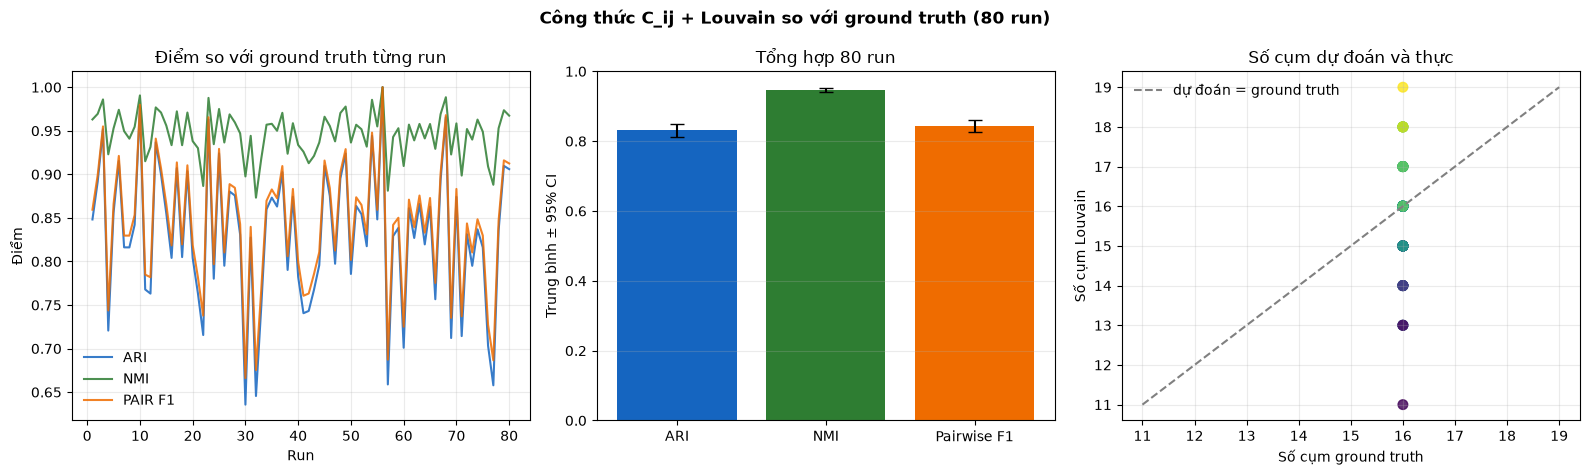

Đã lưu: /content/drive/MyDrive/Colab Notebooks/data/cij_vs_ground_truth_results/cij_vs_ground_truth_80runs.png
Tỷ lệ missing và m_ij trung bình:


,mean
missing_f_rate,0.0
missing_e_rate,0.0
pair_fraction_m0,0.0
pair_fraction_m1,0.0
pair_fraction_m2,1.0


In [8]:
# Kết quả trung bình, 95% CI và biểu đồ so với ground truth.
metrics = ['ari', 'nmi', 'pair_f1']
report_rows = []
for metric in metrics:
    values = summary_df[metric]
    report_rows.append({
        'metric': metric, 'mean': values.mean(), 'std': values.std(ddof=1),
        'ci95': 1.96 * values.std(ddof=1) / np.sqrt(len(values)),
        'min': values.min(), 'max': values.max(), 'n_runs': len(values),
    })
report_df = pd.DataFrame(report_rows)
display(report_df)
display(summary_df[['n_reports', 'n_clusters_pred', 'n_clusters_gt', 'n_edges', 'runtime_seconds']].describe())

FIG_PATH = RESULTS_ROOT / 'cij_vs_ground_truth_80runs.png'
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
x = np.arange(1, 81)
for metric, color in zip(metrics, ['#1565c0', '#2e7d32', '#ef6c00']):
    axes[0].plot(x, summary_df[metric], label=metric.upper().replace('_', ' '), color=color, alpha=0.85)
axes[0].set(xlabel='Run', ylabel='Điểm', title='Điểm so với ground truth từng run')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

means = report_df['mean'].to_numpy()
axes[1].bar(['ARI', 'NMI', 'Pairwise F1'], means, yerr=report_df['ci95'],
            capsize=5, color=['#1565c0', '#2e7d32', '#ef6c00'])
axes[1].set(ylim=(0, 1), ylabel='Trung bình ± 95% CI', title='Tổng hợp 80 run')
axes[1].grid(axis='y', alpha=0.25)

axes[2].scatter(summary_df['n_clusters_gt'], summary_df['n_clusters_pred'],
                c=summary_df['ari'], cmap='viridis', s=48, alpha=0.85)
lo = min(summary_df['n_clusters_gt'].min(), summary_df['n_clusters_pred'].min())
hi = max(summary_df['n_clusters_gt'].max(), summary_df['n_clusters_pred'].max())
axes[2].plot([lo, hi], [lo, hi], '--', color='gray', label='dự đoán = ground truth')
axes[2].set(xlabel='Số cụm ground truth', ylabel='Số cụm Louvain', title='Số cụm dự đoán và thực')
axes[2].legend(frameon=False)
axes[2].grid(alpha=0.25)

fig.suptitle('Công thức C_ij + Louvain so với ground truth (80 run)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=180, bbox_inches='tight')
plt.show()
print('Đã lưu:', FIG_PATH)
print('Tỷ lệ missing và m_ij trung bình:')
display(summary_df[['missing_f_rate', 'missing_e_rate',
                    'pair_fraction_m0', 'pair_fraction_m1', 'pair_fraction_m2']].mean().to_frame('mean'))


## Cách đọc

- ARI/NMI/pairwise F1 càng gần 1 thì cụm Louvain càng khớp ground truth.
- Pairwise F1 đánh giá việc hai báo cáo có được gom cùng sự cố hay không, nên không bị ảnh hưởng bởi tên/ID cụm tùy ý của Louvain.
- ARI/NMI/F1 được tính sau prediction và loại các báo cáo có `gt_cluster = -1`, đúng giao thức evaluator của bộ dữ liệu.
- CSV assignments giữ cả nhãn dự đoán và nhãn thật để kiểm tra từng báo cáo.
- Nếu `pair_fraction_m2 = 1`, dữ liệu gốc không có thiếu F/E; công thức vẫn được chạy đúng nhưng nhánh $m_{ij}=0,1$ chỉ được xác nhận bằng unit test.


In [9]:
from google.colab import files
files.download(str(SUMMARY_PATH))
files.download(str(ASSIGNMENT_PATH))
files.download(str(FIG_PATH))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>